query 由输入经过变换得到

由于并行运算，自注意力无法执行顺序操作（损失了序列信息）
所以未来使用序列的顺序信息，需要在输入表示中添加位置编码来注入信息位置（可以学习得到，也可以直接固定）

常用的一种位置编码方式为正余弦固定位置编码

In [3]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class PositionalEncoding(nn.Module):
    """
    正弦余弦固定位置编码（Transformer原文标准实现）
    为序列补充绝对位置信息，同时天然支持相对位置线性变换，无任何可学习参数。

    Args:
        d_model: 词嵌入/编码的特征维度，必须为偶数
        dropout: Dropout概率，默认0.1
        max_len: 预支持的最大序列长度，默认5000
    """
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()

        # 工程强校验：维度必须为偶数，保证sin/cos成对对齐
        if d_model % 2 != 0:
            raise ValueError(f"d_model 必须为偶数，当前输入: {d_model}")

        self.dropout = nn.Dropout(p=dropout)
        self.d_model = d_model

        # 预计算位置编码矩阵
        position = torch.arange(max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]
        # 指数形式计算频率衰减项，数值更稳定（等价于 1/10000^(2i/d_model)）
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )

        # 初始化编码矩阵
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)  # 偶数维 sin
        pe[:, 1::2] = torch.cos(position * div_term)  # 奇数维 cos

        # 增加batch维度，注册为模型buffer（随模型自动迁移设备、保存到state_dict）
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: 输入词嵌入，形状 [batch_size, seq_len, d_model]
        Returns:
            叠加位置编码后的张量，形状与输入一致
        """
        seq_len = x.size(1)
        # 直接取对应长度的位置编码相加，buffer自动与输入同设备
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x)


def plot_positional_encoding(
    pos_enc: PositionalEncoding,
    seq_len: int,
    col_indices: list,
    figsize: tuple = (6, 2.5)
):
    """
    绘制指定维度的位置编码随位置变化的曲线
    Args:
        pos_enc: 位置编码实例
        seq_len: 绘制的序列长度
        col_indices: 要展示的维度索引列表（如 [6,7,8,9]）
        figsize: 画布尺寸
    """
    # 取出位置编码数据
    pe_matrix = pos_enc.pe[0, :seq_len, :].cpu().numpy()
    positions = list(range(seq_len))

    # 创建画布
    plt.figure(figsize=figsize, dpi=100)
    for col in col_indices:
        plt.plot(positions, pe_matrix[:, col], label=f"Col {col}")

    # 坐标轴与图例
    plt.xlabel("Row (position)")
    plt.ylabel("Encoding value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [4]:
class PositionalEncoding(nn.Module):
    """
    正弦余弦固定位置编码（Transformer原文标准实现）
    为序列补充绝对位置信息，同时天然支持相对位置线性变换，无任何可学习参数。
    Args:
        d_model: 词嵌入/编码的特征维度，必须为偶数
        dropout: Dropout概率，默认0.1
        max_len: 预支持的最大序列长度，默认5000
    """
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()

        # 工程强校验：维度必须为偶数，保证sin/cos成对对齐
        if d_model % 2 != 0:
            raise ValueError(f"d_model 必须为偶数，当前输入: {d_model}")

        self.dropout = nn.Dropout(p=dropout)
        self.d_model = d_model

        # 预计算位置编码矩阵
        position = torch.arange(max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]
        # 指数形式计算频率衰减项，数值更稳定（等价于 1/10000^(2i/d_model)）
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )

        # 初始化编码矩阵
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)  # 偶数维 sin
        pe[:, 1::2] = torch.cos(position * div_term)  # 奇数维 cos

        # 增加batch维度，注册为模型buffer（随模型自动迁移设备、保存到state_dict）
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: 输入词嵌入，形状 [batch_size, seq_len, d_model]
        Returns:
            叠加位置编码后的张量，形状与输入一致
        """
        seq_len = x.size(1)
        # 直接取对应长度的位置编码相加，buffer自动与输入同设备
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x)

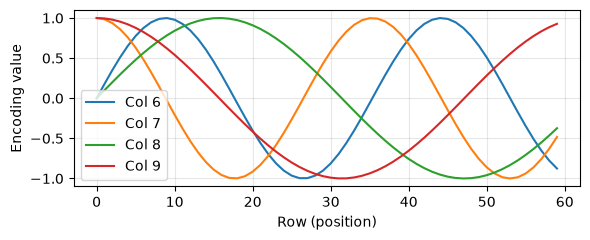

In [5]:
# 参数设置
encoding_dim, num_steps = 32, 60

# 初始化位置编码
pos_encoding = PositionalEncoding(d_model=encoding_dim, dropout=0)
pos_encoding.eval()

# 前向验证形状
dummy_input = torch.zeros(1, num_steps, encoding_dim)
_ = pos_encoding(dummy_input)

# 绘制第6~9列的曲线
plot_positional_encoding(pos_encoding, num_steps, col_indices=[6, 7, 8, 9])